In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from enum import Enum

In [2]:
# Dictionary to hold our parsed data before converting to a DataFrame
# Format: { 'problem_name': { ('group', 'metric_name'): value } }
data_dict = {}
current_problem = None

# Define the prefixes we want to group by
prefixes = ['num_', 'dd_', 'ar_', 'ggraph_', 'solve_', 'tr_']

def read_into_data_dict(file):
    for line in file:
        line = line.strip()
                    
        if not line:
            continue
        
        # Set the current problem name for the row index
        if line.startswith("BEGINPROBLEM:"):
            current_problem = line.split(":", 1)[1]
            data_dict[current_problem] = {}
            continue
        
        if "=" in line and current_problem is not None:
            key, value_str = line.split("=", 1)
            
            # Parse lists or integers
            if value_str.startswith("[") and value_str.endswith("]"):
                inner_values = value_str[1:-1].strip()
                if inner_values:
                    parsed_value = [int(x) for x in inner_values.split(",")]
                else:
                    parsed_value = []
            else:
                parsed_value = int(value_str)
            
            # Determine 3-level grouping (Group, Subgroup, Metric)
            group = "other"
            subgroup = "base"
            metric = key
            
            for pref in prefixes:
                if key.startswith(pref):
                    group = pref
                    
                    # Further group specific dd_ metrics into sub-categories
                    if key.startswith("dd_thm_matches:"):
                        subgroup = "thm_matches"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    elif key.startswith("dd_thm_duration:"):
                        subgroup = "thm_duration"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    
                    break
            
            # Store data with a 3-part tuple key for the MultiIndex
            data_dict[current_problem][(group, subgroup, metric)] = parsed_value

In [3]:
file1 = open("imo/profiler.txt", "r")
read_into_data_dict(file1)
file2 = open("110-problems/profiler.txt", "r")
read_into_data_dict(file2)
file3 = open("mo-tg-225/profiler.txt", "r")
read_into_data_dict(file3)
file4 = open("jgex-231/profiler.txt", "r")
read_into_data_dict(file4)

In [4]:
df = pd.DataFrame.from_dict(data_dict, orient='index')
    
# Convert the tuple columns into a 3-level pandas MultiIndex
if not df.empty:
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Group', 'Subgroup', 'Metric'])

In [5]:
imo_problem = df.loc[df.index.str.startswith("imo")]
problem_110 = df.loc[df.index.str.startswith("110")]
mo_tg_225_problem = df.loc[df.index.str.startswith("MO-TG-225")]
jgex_problem = df.loc[df.index.str.startswith("complete")]

In [6]:
N = len(df)
df.head()

Group              num_                                solve_  \
Subgroup           base                                  base   
Metric      num_success num_params num_duration solve_success   
imo-2000-1            1          6          178           1.0   
imo-2002-2a           1          5          134           1.0   
imo-2002-2b           1          5          259           1.0   
imo-2003-4            1          6          199           1.0   
imo-2004-1            1          6          176           1.0   

Group                                              \
Subgroup                                            
Metric      solve_total_duration solve_iterations   
imo-2000-1             5330119.0              4.0   
imo-2002-2a            4401528.0              3.0   
imo-2002-2b             426213.0              2.0   
imo-2003-4             9165030.0              3.0   
imo-2004-1             3885111.0              4.0   

Group                                       dd_                           \
Subgroup                                   base                            
Metric                              dd_duration           dd_total_preds   
imo-2000-1    [40942, 942451, 1401769, 2537144]  [243, 1815, 2278, 4176]   
imo-2002-2a            [14373, 265680, 3912170]         [316, 844, 2964]   
imo-2002-2b                     [14764, 264691]               [316, 846]   
imo-2003-4           [130420, 3373692, 5234415]        [395, 4189, 5190]   
imo-2004-1   [20690, 1032314, 1018425, 1524870]  [317, 1303, 1416, 1707]   

Group                                               ...               ar_  \
Subgroup            thm_duration                    ...              base   
Metric          circle_coll_perp       circle_cong  ...     ar_total_rows   
imo-2000-1    [8, 179, 181, 201]   [1, 50, 49, 59]  ...  [42, 73, 80, 85]   
imo-2002-2a         [8, 71, 430]      [1, 34, 138]  ...      [34, 48, 64]   
imo-2002-2b             [11, 81]           [2, 22]  ...          [34, 48]   
imo-2003-4        [37, 420, 402]     [8, 127, 118]  ...      [43, 86, 93]   
imo-2004-1   [54, 287, 250, 266]  [14, 76, 71, 79]  ...  [66, 73, 73, 75]   

Group                         ggraph_                           \
Subgroup                         base                            
Metric             ggraph_duration_dd       ggraph_duration_ar   
imo-2000-1   [2015, 6293, 1773, 5472]  [1921, 658, 1618, 1828]   
imo-2002-2a        [1702, 2259, 5101]        [990, 2646, 4460]   
imo-2002-2b              [1520, 2225]             [1028, 2761]   
imo-2003-4        [2468, 14610, 5005]       [4197, 3304, 3118]   
imo-2004-1    [4599, 2843, 804, 2065]     [3011, 68, 2209, 53]   

Group                                                                       \
Subgroup                                                                     
Metric      ggraph_num_preds_dd ggraph_num_preds_ar     ggraph_total_nodes   
imo-2000-1     [61, 30, 14, 17]   [115, 13, 84, 71]  [386, 703, 929, 1170]   
imo-2002-2a       [15, 132, 32]       [34, 148, 50]        [161, 447, 595]   
imo-2002-2b           [17, 132]           [34, 148]             [163, 449]   
imo-2003-4        [140, 72, 29]     [236, 122, 122]      [507, 1232, 1612]   
imo-2004-1      [90, 24, 11, 2]     [125, 4, 59, 2]   [520, 662, 792, 810]   

Group              tr_                                         
Subgroup          base                                         
Metric      tr_success tr_sol_depth tr_sol_length tr_duration  
imo-2000-1         1.0         12.0          51.0      2021.0  
imo-2002-2a        1.0         11.0          46.0      1518.0  
imo-2002-2b        1.0          9.0          31.0       912.0  
imo-2003-4         1.0         12.0          94.0      3910.0  
imo-2004-1         1.0         10.0          45.0      1286.0  

[5 rows x 129 columns]

In [7]:
solve_total_duration = df[("solve_", "base", "solve_total_duration")]
dd_total_preds = df[("dd_", "base", "dd_total_preds")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
ar_total_eqs = df[("ar_", "base", "ar_total_cols")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
ggraph_total_nodes = df[("ggraph_", "base", "ggraph_total_nodes")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
tr_sol_length = df[("tr_", "base", "tr_sol_length")]
tr_sol_depth = df[("tr_", "base", "tr_sol_depth")]
dd_duration = df[("dd_", "base", "dd_duration")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)
ar_duration = df[("ar_", "base", "ar_duration")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)
synthesis_duration = df[("ggraph_", "base", "ggraph_duration_dd")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs) + df[("ggraph_", "base", "ggraph_duration_ar")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)

In [8]:
# add a "Source" column to the df based on the imo_problem, problem_110, mo_tg_225_problem and jgex_problem indices
df["source"] = "Other"
df.loc[problem_110.index, "source"] = "Chou-Angle-110"
df.loc[jgex_problem.index, "source"] = "JGEX-60"
df.loc[imo_problem.index, "source"] = "IMO-AG-30"
df.loc[mo_tg_225_problem.index, "source"] = "MO-TG-225-25"
assert (df["source"] == "Other").sum() == 0, "Some problems were not assigned a source"
# sort the df rows so that the "source" column is in the order of "Chou-Angle-110", "JGEX-60", "IMO-AG-30", "MO-TG-225-25", "Other"
df["source"] = pd.Categorical(df["source"], categories=["Chou-Angle-110", "JGEX-60", "IMO-AG-30", "MO-TG-225-25"], ordered=True)
df = df.sort_values("source")

In [9]:
# assemble a dataframe of the above 4 series, with the index as the problem name
df_summary = pd.DataFrame({
    "solve_total_duration": solve_total_duration,
    "dd_total_preds": dd_total_preds,
    "ar_total_cols": ar_total_eqs,
    "ggraph_total_nodes": ggraph_total_nodes,
    "tr_sol_length": tr_sol_length,
    "tr_sol_depth": tr_sol_depth,
    "source": df["source"]
})
df_summary.head()

,solve_total_duration,dd_total_preds,ar_total_cols,ggraph_total_nodes,tr_sol_length,tr_sol_depth,source
110-1,89301.0,226.0,16.0,178.0,17.0,7.0,Chou-Angle-110
110-10,71949.0,262.0,7.0,163.0,17.0,8.0,Chou-Angle-110
110-100,643983.0,1080.0,16.0,120.0,31.0,10.0,Chou-Angle-110
110-101,186397.0,411.0,14.0,205.0,15.0,7.0,Chou-Angle-110
110-102,32861.0,252.0,10.0,148.0,10.0,5.0,Chou-Angle-110


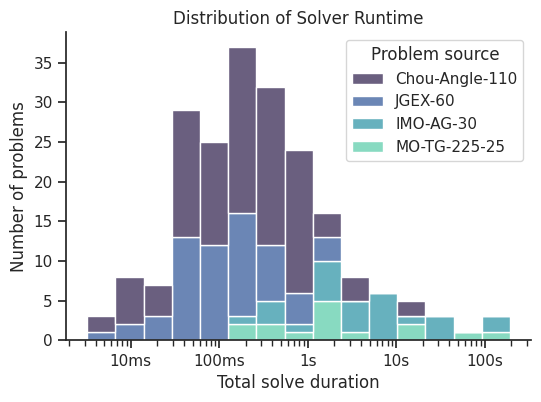

In [76]:
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)

sns.histplot(
    df_summary, 
    x="solve_total_duration", ax=ax, bins=15, log_scale=True, 
    hue="source", multiple="stack", palette="mako", 
)
ax.set_title("Distribution of Solver Runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Number of problems")
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
# rename the legend to say "Problem source"
ax.legend_.set_title("Problem source")

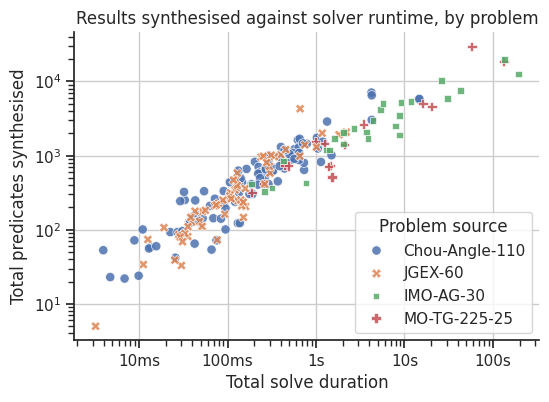

In [81]:
# Scatter plot of total predicates vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)

sns.scatterplot(
    df_summary,
    x="solve_total_duration", y="dd_total_preds", hue="source", style="source",
    ax=ax, alpha=0.85, s=45
)

ax.set_title("Results synthesised against solver runtime, by problem")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total predicates synthesised")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
# move the legend into the bottom_right
ax.legend(loc='lower right', title="Problem source")
ax.grid()

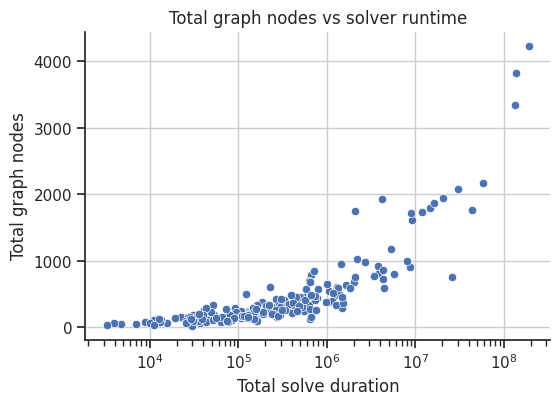

In [15]:
# Scatter plot of total graph nodes vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=ggraph_total_nodes, x=solve_total_duration, ax=ax)
ax.set_title("Total graph nodes vs solver runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total graph nodes")
ax.set_xscale('log')
ax.grid()

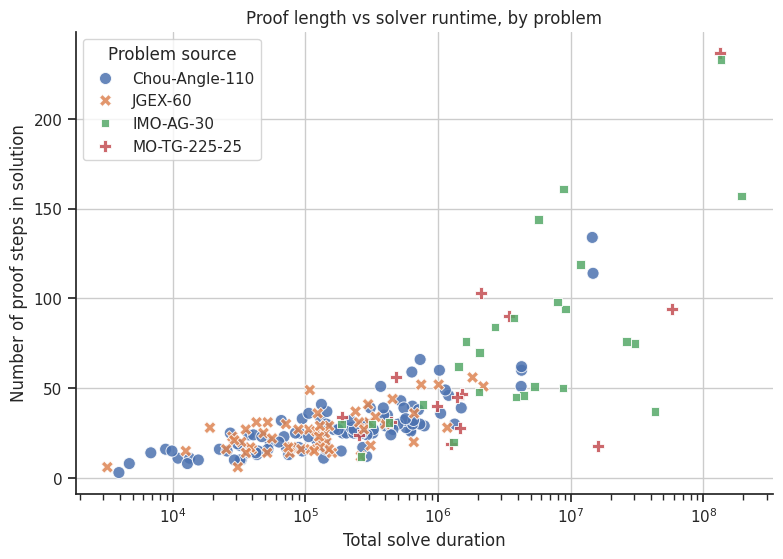

In [75]:
# Scatter plot of proof length vs solve duration
f, ax = plt.subplots(figsize=(9, 6))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(
    df_summary,
    x="solve_total_duration", y="tr_sol_length", hue="source", style="source",
    ax=ax, alpha=0.85, s=75
)
ax.set_title("Proof length vs solver runtime, by problem")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Number of proof steps in solution")
ax.set_xscale('log')
# ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
# ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
ax.legend(title="Problem source")
ax.grid()

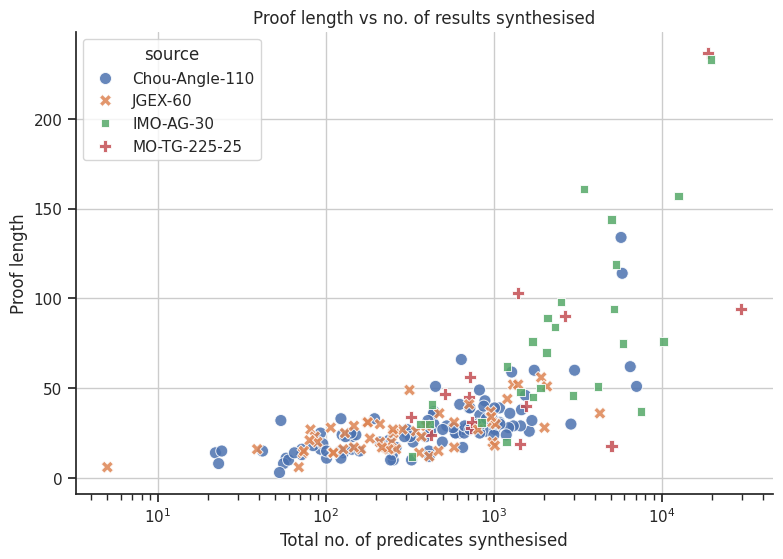

In [ ]:
# Scatter plot of proof length vs no. of results synthesised
f, ax = plt.subplots(figsize=(9, 6))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(
    df_summary,
    x="dd_total_preds", y="tr_sol_length", hue="source", style="source",
    ax=ax, alpha=0.85, s=75
)
ax.set_title("Proof length vs no. of results generated, by problem")
ax.set_xlabel("Total no. of predicates synthesised")
ax.set_ylabel("Proof length")
ax.set_xscale('log')
ax.grid()

/tmp/ipykernel_38474/3406200395.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


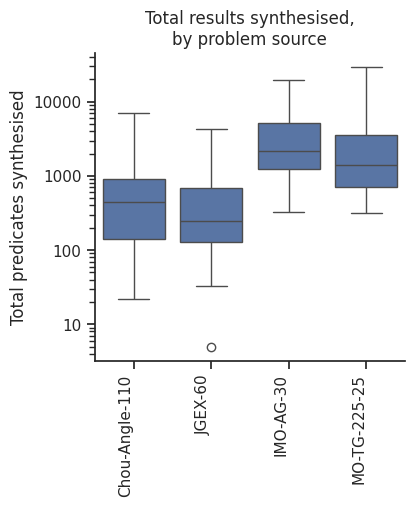

In [100]:
# Box plot 
f, ax = plt.subplots(figsize=(4, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.boxplot(
    df_summary, x="source", y="dd_total_preds", ax=ax, log_scale=True
)
ax.set_title("Total results synthesised,\nby problem source")
ax.set_ylabel("Total predicates synthesised")
# make the x-axis tick labels vertical
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
# remove the x-axis label
ax.set_xlabel("")
# make the y-axis tick labels normal numbers
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

/tmp/ipykernel_38474/2957415134.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


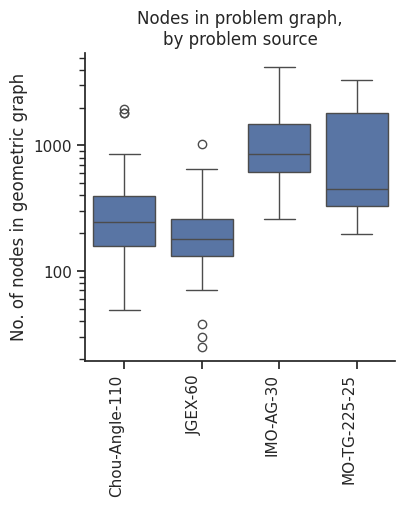

In [102]:
# Box plot 
f, ax = plt.subplots(figsize=(4, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.boxplot(
    df_summary, x="source", y="ggraph_total_nodes", ax=ax, log_scale=True
)
ax.set_title("Nodes in problem graph,\nby problem source")
ax.set_ylabel("No. of nodes in geometric graph")
# make the x-axis tick labels vertical
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
# remove the x-axis label
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

In [18]:
df["dd_", "thm_duration"]

/tmp/ipykernel_38474/1499160504.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df["dd_", "thm_duration"]


Metric,circle_coll_perp,circle_cong,circle_eqangle_perp,circle_perp_eqangle,coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic,coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri,coll_coll_ncoll_para_cong_cong_para,coll_coll_ncoll_para_eqratio_para,coll_coll_ncoll_sameside_p_sameside_p_eqratio_cyclic,cong_cong_cong_ncoll_contri,...,para_coll_coll_ncoll_simtri,para_coll_ncoll_eqangle,para_diff_coll,para_para_eqangle_ncoll_simtri,para_para_ncoll_cong,para_para_para_ncoll_simtri,perp_midp_cong,perp_perp_diff_cyclic,perp_perp_diff_perp,perp_perp_ncoll_para
110-78,"[6, 6, 8, 5]","[2, 2, 2, 1]","[1, 1, 1, 1]","[1, 1, 2, 1]","[252, 309, 282, 275]","[230, 243, 272, 293, 303, 313, 366, 381]","[1575, 1847, 1716, 1721]","[1557, 1806, 1743, 1710]","[230, 271, 266, 253]","[79, 383, 198, 539]",...,"[6, 7, 81, 94]","[3, 3, 80, 88]","[3, 3, 12, 12]","[3, 3, 327, 427]","[2, 3, 65, 75]","[3, 3, 265, 348]","[70, 69, 137, 160]","[408, 206, 566, 445]","[411, 338, 831, 910]","[988, 763, 2731, 3129]"
110-73,"[9, 11]","[2, 2]","[2, 2]","[2, 2]","[171, 279]","[158, 157, 317, 298]","[561, 2466]","[543, 2144]","[148, 250]","[5, 8]",...,"[43, 11]","[29, 4]","[76, 4]","[149, 4]","[53, 4]","[121, 3]","[119, 95]","[550, 353]","[710, 698]","[2003, 1989]"
110-72,"[4, 6, 10]","[2, 1, 2]","[1, 1, 2]","[1, 1, 1]","[144, 162, 216]","[146, 139, 149, 152, 197, 203]","[485, 533, 648]","[486, 521, 644]","[133, 146, 180]","[8, 4, 12]",...,"[4, 11, 8]","[2, 4, 4]","[2, 4, 9]","[2, 5, 4]","[2, 4, 4]","[2, 3, 4]","[62, 80, 84]","[336, 272, 243]","[313, 440, 389]","[746, 935, 836]"
110-71,"[36, 31]","[9, 8]","[12, 983]","[19, 19]","[140, 140]","[151, 135, 170, 149]","[492, 493]","[478, 489]","[160, 158]","[378, 368]",...,"[34, 55]","[166, 42]","[6, 8]","[87, 105]","[27, 29]","[71, 86]","[61, 72]","[334, 222]","[323, 365]","[743, 831]"
110-70,[32],[9],[12],[18],[265],"[296, 260]",[1193],[1178],[321],[1139],...,[3],[2],[2],[3],[2],[1],[1],[2],[1],[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MO-TG-225-5,"[18, 13, 12]","[2, 3, 3]","[2, 4, 3]","[2, 3, 2]","[678, 439, 427]","[773, 657, 771, 647, 1105, 917]","[3797, 3915, 3097]","[3934, 4073, 3062]","[962, 522, 385]","[20, 11, 20]",...,"[41, 14, 12]","[6, 5, 7]","[5, 5, 12]","[5, 6, 7]","[6, 6, 6]","[7, 5, 6]","[212, 195, 242]","[1898, 692, 595]","[1210, 1159, 1009]","[2943, 2793, 2441]"
MO-TG-225-4,"[12, 9]","[1, 2]","[1, 2]","[1, 1]","[4069, 3957]","[5199, 4396, 4794, 4747]","[29233, 27626]","[26149, 25551]","[4243, 4120]","[496, 2231]",...,"[235, 1650]","[405, 4245]","[9, 116]","[60, 819]","[32, 778]","[53, 725]","[389, 228]","[414, 570]","[1384, 1347]","[7828, 7274]"
MO-TG-225-3,"[21, 10, 9]","[3, 3, 3]","[3, 2, 2]","[3, 2, 2]","[2441, 1807, 1652]","[2541, 2582, 1892, 1869, 2284, 2166]","[15860, 14144, 12225]","[17274, 15296, 15249]","[2042, 1980, 1985]","[757, 712, 7596]",...,"[3, 2218, 875]","[2, 6351, 905]","[2, 88, 69]","[3, 2855, 8099]","[2, 2234, 545]","[2, 3281, 7089]","[3, 7, 5]","[2, 3, 3]","[2, 3, 3]","[3, 3, 3]"
MO-TG-225-10,"[73, 31, 79, 83]","[12, 10, 28, 29]","[25, 2475, 14316, 23102]","[24, 25, 58, 860]","[3106, 3042, 2678, 16842]","[3447, 3601, 4304, 3882, 44675, 7622, 23919, 5...","[28561, 29568, 22879, 24307]","[26517, 27031, 22950, 22745]","[3743, 3607, 3770, 3411]","[933, 1316, 2145, 2132]",...,"[5, 463, 257, 289]","[2, 650, 258, 292]","[2, 29, 23, 105]","[3, 335, 1373, 1601]","[2, 159, 175, 220]","[2, 317, 979, 1308]","[365, 324, 386, 399]","[1010, 1161, 1080, 1140]","[2418, 2425, 2539, 2550]","[9350, 11713, 11975, 12161]"


/tmp/ipykernel_38474/4256969994.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs)


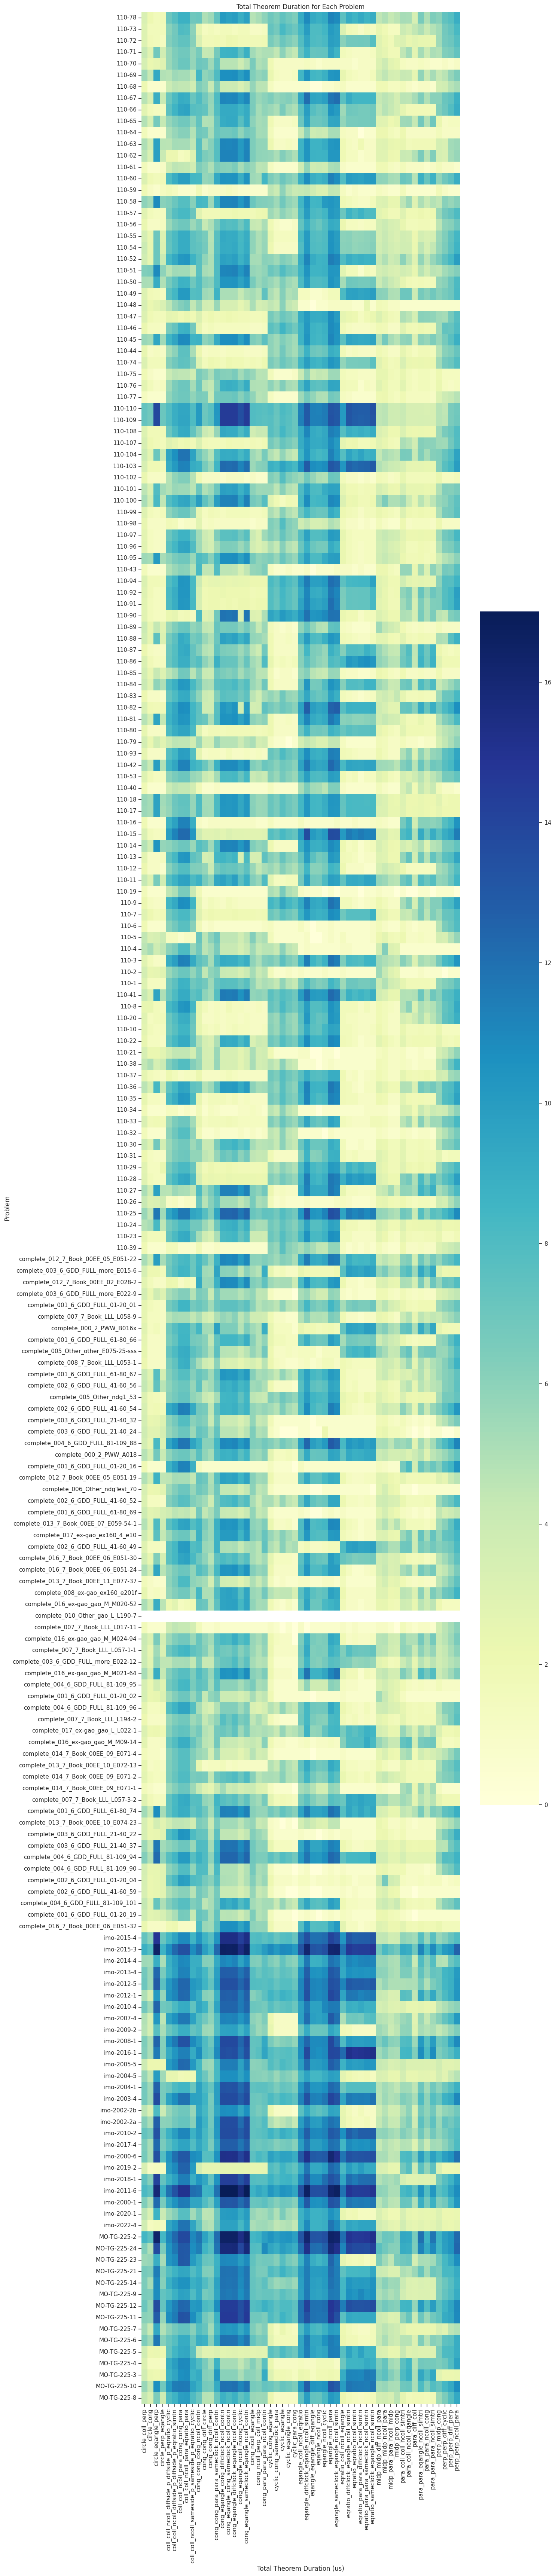

In [21]:
# Create another dataframe where every entry is equal to the sum of the elements in the list in df["dd_", "thm_duration"]
df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs)

# Plot a heatmap of df_thm_duration_per_problem, with the index as the y-axis and the values as the x-axis
plt.figure(figsize=(15,N // 3))
sns.heatmap(np.log(df_thm_duration_per_problem + 1), annot=False, fmt=".1f", cmap="YlGnBu")
plt.xlabel("Total Theorem Duration (us)")
plt.ylabel("Problem")
plt.title("Total Theorem Duration for Each Problem")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
df_thm_duration_sum = df_thm_duration_per_problem.sum()
df_thm_duration_sum.sort_values()

Metric
midp_perp_cong                                             11371.0
midp_para_para_ncoll_midp                                  13041.0
para_diff_coll                                             13168.0
circle_cong                                                20176.0
midp_midp_diff_ncoll_para                                  20510.0
midp_midp_ncoll_para                                       29314.0
circle_coll_perp                                           47953.0
circle_perp_eqangle                                        48715.0
para_para_ncoll_cong                                       72613.0
cong_cong_diff_perp                                        74675.0
perp_midp_cong                                             77415.0
cong_ncoll_perp_coll_midp                                  95726.0
para_coll_coll_ncoll_simtri                                98524.0
cong_ncoll_eqangle                                        113757.0
para_coll_ncoll_eqangle                                

In [24]:
df_thm_matches_sum = df[("dd_", "thm_matches")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs).sum()
df_thm_matches_sum.sort_values()

/tmp/ipykernel_38474/4280302156.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_matches_sum = df[("dd_", "thm_matches")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs).sum()


Metric
eqangle_ncoll_para                                          0.0
perp_perp_ncoll_para                                        0.0
cyclic_cong_sameclock_para                                  4.0
coll_coll_ncoll_para_cong_cong_para                         8.0
coll_coll_ncoll_para_eqratio_para                           8.0
coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri       16.0
midp_para_para_ncoll_midp                                  16.0
circle_coll_perp                                           20.0
cong_ncoll_perp_coll_midp                                  32.0
eqratio_coll_ncoll_eqangle                                 40.0
coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic       64.0
circle_eqangle_perp                                        72.0
cyclic_cong_eqangle                                        73.0
midp_perp_cong                                             80.0
cyclic_eqangle_cong                                       101.0
eqangle_eqangle_diff_eqangle     

In [25]:
outlier = (df_thm_duration_sum.values > 1e6) & (df_thm_matches_sum.values < 10)
print(sum(outlier))

4


In [29]:
# join df_thm_duration_sum and df_thm_matches_sum into a single dataframe
df_thms = pd.DataFrame({
    "thm_duration_sum": df_thm_duration_sum,
    "thm_matches_sum": df_thm_matches_sum
})
df_thms["thm_first_match"] = df_thms.index.map(lambda idx: idx.split("_")[0])

Outlier problems with high theorem duration but low matches:
coll_coll_ncoll_para_cong_cong_para
coll_coll_ncoll_para_eqratio_para
eqangle_ncoll_para
perp_perp_ncoll_para


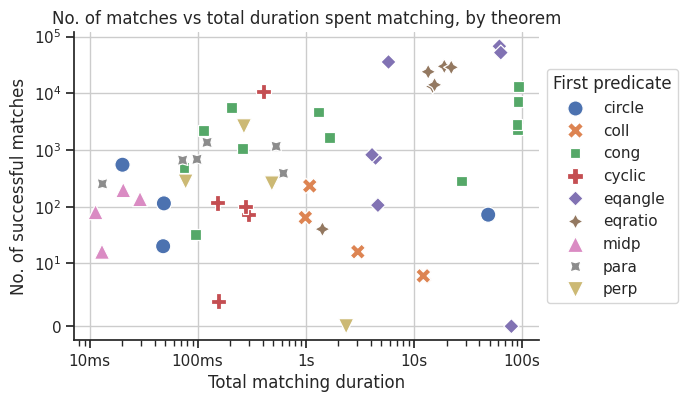

In [59]:
# Scatter plot of df_thm_matches_sum (y-axis) against df_thm_duration_sum (x-axis)
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
# sns.scatterplot(x=df_thm_duration_sum[outlier], y=df_thm_matches_sum[outlier], ax=ax, color='red')

ax.set_title("No. of matches vs total duration spent matching, by theorem")
ax.set_xlabel("Total matching duration")
ax.set_ylabel("No. of successful matches")
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=10)
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
ax.grid()

sns.scatterplot(
    data=df_thms, 
    x="thm_duration_sum", y="thm_matches_sum", hue="thm_first_match", style="thm_first_match",
    ax=ax, s=120
)
# ensure the legend is outside the plot area
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="First predicate")

# Print out the outlier theorem names
print("Outlier problems with high theorem duration but low matches:")
for problem in df_thm_duration_sum.index[outlier]:
    print(problem)

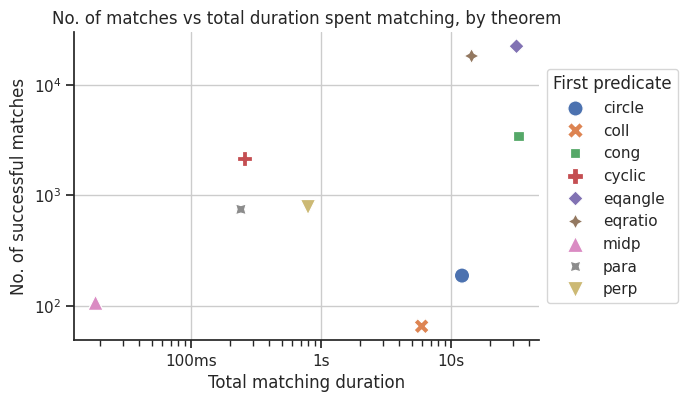

In [82]:
# Now do an aggregate scatter plot of matches against duration, for each "thm_first_match" category, averaged over all theorems in that category
df_thms_avg = df_thms.groupby("thm_first_match").mean().reset_index()
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
# sns.scatterplot(x=df_thm_duration_sum[outlier], y=df_thm_matches_sum[outlier], ax=ax, color='red')

ax.set_title("No. of matches vs total duration spent matching, by theorem")
ax.set_xlabel("Total matching duration")
ax.set_ylabel("No. of successful matches")
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=10)
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
ax.grid()

sns.scatterplot(
    data=df_thms_avg, 
    x="thm_duration_sum", y="thm_matches_sum", hue="thm_first_match", style="thm_first_match",
    ax=ax, s=120
)
# ensure the legend is outside the plot area
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="First predicate")

In [135]:
df_durations = pd.DataFrame({
    "dd_duration": dd_duration,
    "ar_duration": ar_duration,
    "synthesis_duration": synthesis_duration,
    "total_duration": solve_total_duration,
    "source": df["source"]
})
df_durations = df_durations.sort_values("total_duration")

In [136]:
df_durations

,dd_duration,ar_duration,synthesis_duration,total_duration,source
complete_007_7_Book_LLL_L017-11,1260.0,1667.0,124.0,3222.0,JGEX-60
110-59,1310.0,1720.0,698.0,3939.0,Chou-Angle-110
110-40,3285.0,764.0,347.0,4718.0,Chou-Angle-110
110-21,2094.0,4043.0,442.0,6855.0,Chou-Angle-110
110-48,3769.0,3860.0,948.0,8855.0,Chou-Angle-110
...,...,...,...,...,...
MO-TG-225-24,55006136.0,2708808.0,121548.0,57840376.0,MO-TG-225-25
MO-TG-225-2,130132911.0,2770456.0,112989.0,133018590.0,MO-TG-225-25
imo-2015-3,129177178.0,6317865.0,131188.0,135630400.0,IMO-AG-30
imo-2011-6,178966132.0,14390255.0,140605.0,193499781.0,IMO-AG-30


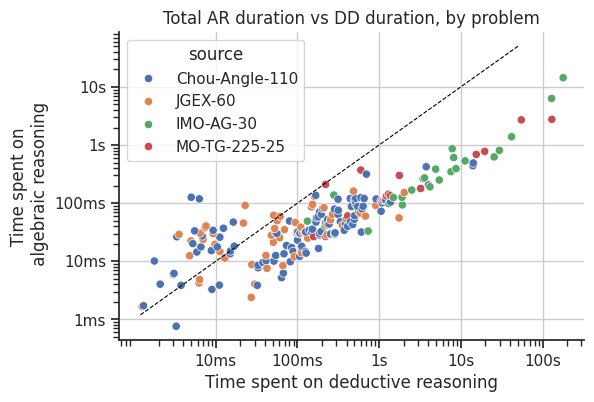

In [144]:
# scatter plot of ar_duration (y-axis) against dd_duration (x-axis)
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)

ax.plot([1.2e3, 5e7], [1.2e3, 5e7], color='black', linestyle='--', linewidth=0.8)
sns.scatterplot(
    data=df_durations, x="dd_duration", y="ar_duration", hue="source",
    ax=ax
)

ax.set_title("Total AR duration vs DD duration, by problem")
ax.set_xlabel("Time spent on deductive reasoning")
ax.set_ylabel("Time spent on\n algebraic reasoning")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
ax.set_yticks([1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_yticklabels(['1ms', '10ms', '100ms', '1s', '10s'])
# move the legend into the bottom_right

# draw the line y=x
ax.grid()


In [111]:
(solve_total_duration > 1e7).sum() / solve_total_duration.shape[0]

np.float64(0.057692307692307696)

In [11]:
df_summary.to_csv("profiler_summary.csv")